## Recurrent Neural Networks (RNN)

Дәстүрлі нейрондық желілерден айырмашылығы, RNN-нің **жады** бар. Ол ақпаратты тізбек бойынша сақтайды. Бұл оны мәтін, аудио немесе уақыттық қатарлар (time series) сияқты деректермен жұмыс істеуге таптырмас құрал етеді.

**Негізгі формула:**


Жасырын күй (hidden state)  келесі формула бойынша есептеледі:


$$h_t = \phi(W_{hh}h_{t-1} + W_{xh}x_t + b_h)$$


Мұнда:

$h_t$ — ағымдағы уақыттағы жады.

$x_t$ — кіріс дерегі.

$\phi$ — активация функциясы (әдетте $tanh$).




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

url = 'https://raw.githubusercontent.com/mwitiderrick/stockprice/master/NSE-TATAGLOBAL.csv'
df = pd.read_csv(url)

print(df.head())


         Date    Open    High     Low    Last   Close  Total Trade Quantity  \
0  2018-09-28  234.05  235.95  230.20  233.50  233.75               3069914   
1  2018-09-27  234.55  236.80  231.10  233.80  233.25               5082859   
2  2018-09-26  240.00  240.00  232.50  235.00  234.25               2240909   
3  2018-09-25  233.30  236.75  232.00  236.25  236.10               2349368   
4  2018-09-24  233.55  239.20  230.75  234.00  233.30               3423509   

   Turnover (Lacs)  
0          7162.35  
1         11859.95  
2          5248.60  
3          5503.90  
4          7999.55  


## 3. Деректерді алдын ала өңдеу

In [2]:
data = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        _x = data[i:i + seq_length]
        _y = data[i + seq_length]
        x.append(_x)
        y.append(_y)
    return np.array(x), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()



## 4. RNN Моделін құру

In [3]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

input_size = 1
hidden_size = 64
output_size = 1

model = SimpleRNN(input_size, hidden_size, output_size)


## 5. Модельді жаттықтыру

In [4]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [5/20], Loss: 0.0548
Epoch [10/20], Loss: 0.0472
Epoch [15/20], Loss: 0.0300
Epoch [20/20], Loss: 0.0289


## 6. Болжам жасау және нәтижені визуализациялау

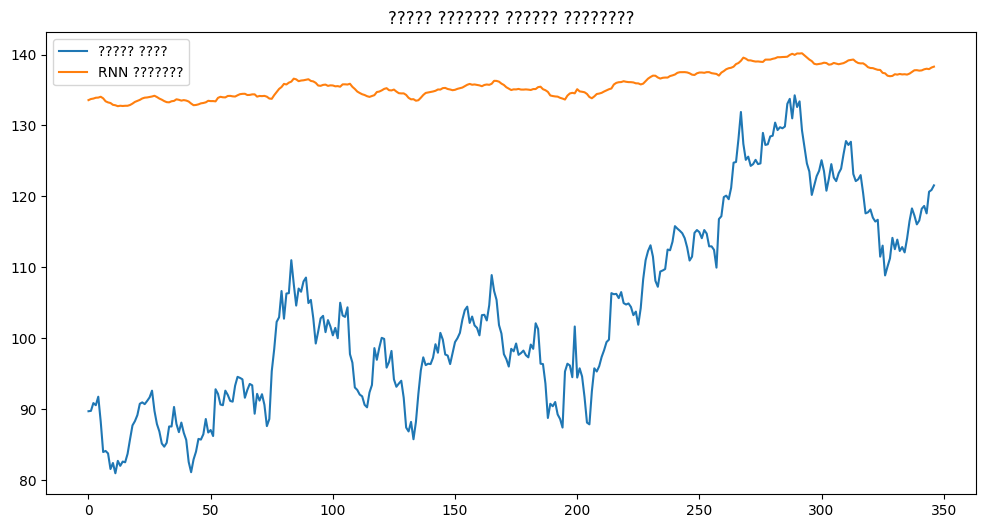

In [5]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test).float()
    predictions = model(X_test_tensor)
    predictions = scaler.inverse_transform(predictions.numpy())
    actual = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 6))
plt.plot(actual, label='????? ????')
plt.plot(predictions, label='RNN ???????')
plt.title('????? ??????? ?????? ????????')
plt.legend()
plt.show()
